In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns

In [2]:
ASCyes = np.load('/home/dell/iHESPplot/ASC/ASCalongallyes.npy')
ASCno = np.load('/home/dell/iHESPplot/ASC/ASCalongallno.npy')

In [3]:
ASCyesm = np.nanmean(ASCyes, axis=0)
ASCnom = np.nanmean(ASCno, axis=0)

/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: Mean of empty slice
  """Entry point for launching an IPython kernel.
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: Mean of empty slice
  


In [4]:
ppp = ASCyesm-ASCnom

In [5]:
data=nc.Dataset('/home/dell/iHESPdata/B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1929-06-01.nc')

lont = data.variables['TLONG'][:428,:]
latt = data.variables['TLAT'][:428,:]

In [6]:
lont[lont==-1]=np.nan
latt[latt==-1]=np.nan
#ppp[ppp==-1]=np.nan

In [7]:
iceyes1 = np.load('/home/dell/iHESPdata/SSH250-338ALLyearyear.npy')
iceyes2 = np.load('/home/dell/iHESPdata/SSH338-500ALLyearyear.npy')
iceno1 = np.load('/home/dell/iHESPdata/SSH250-338ALLnoyearyear.npy')
iceno2 = np.load('/home/dell/iHESPdata/SSH338-500ALLnoyearyear.npy')

In [8]:
ice = (iceyes1+iceyes2)/2
iceno = (iceno1+iceno2)/2

icediff = ice-iceno

In [9]:
ice.shape

(600, 3600)

In [10]:
data=nc.Dataset('/home/dell/iHESPdata/B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1929-06-01.nc')

lont2 = data.variables['TLONG'][:600,:]
latt2 = data.variables['TLAT'][:600,:]

data=nc.Dataset('/media/dell/Elements/new/SDENFsigma1/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0375-06.SDEN_F.nc')
lontu = data.variables['TLONG'][:,:]
lattu = data.variables['TLAT'][:,:]
lontu[lontu ==-1] = np.nan
lattu[lattu ==-1] = np.nan

data222=nc.Dataset('/home/dell/iHESPdata/iHESPocn/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0295-12.nc')
plotvarKMT = data222.variables['KMT'][:,:]


findfont: Font family ['Cambria'] not found. Falling back to DejaVu Sans.


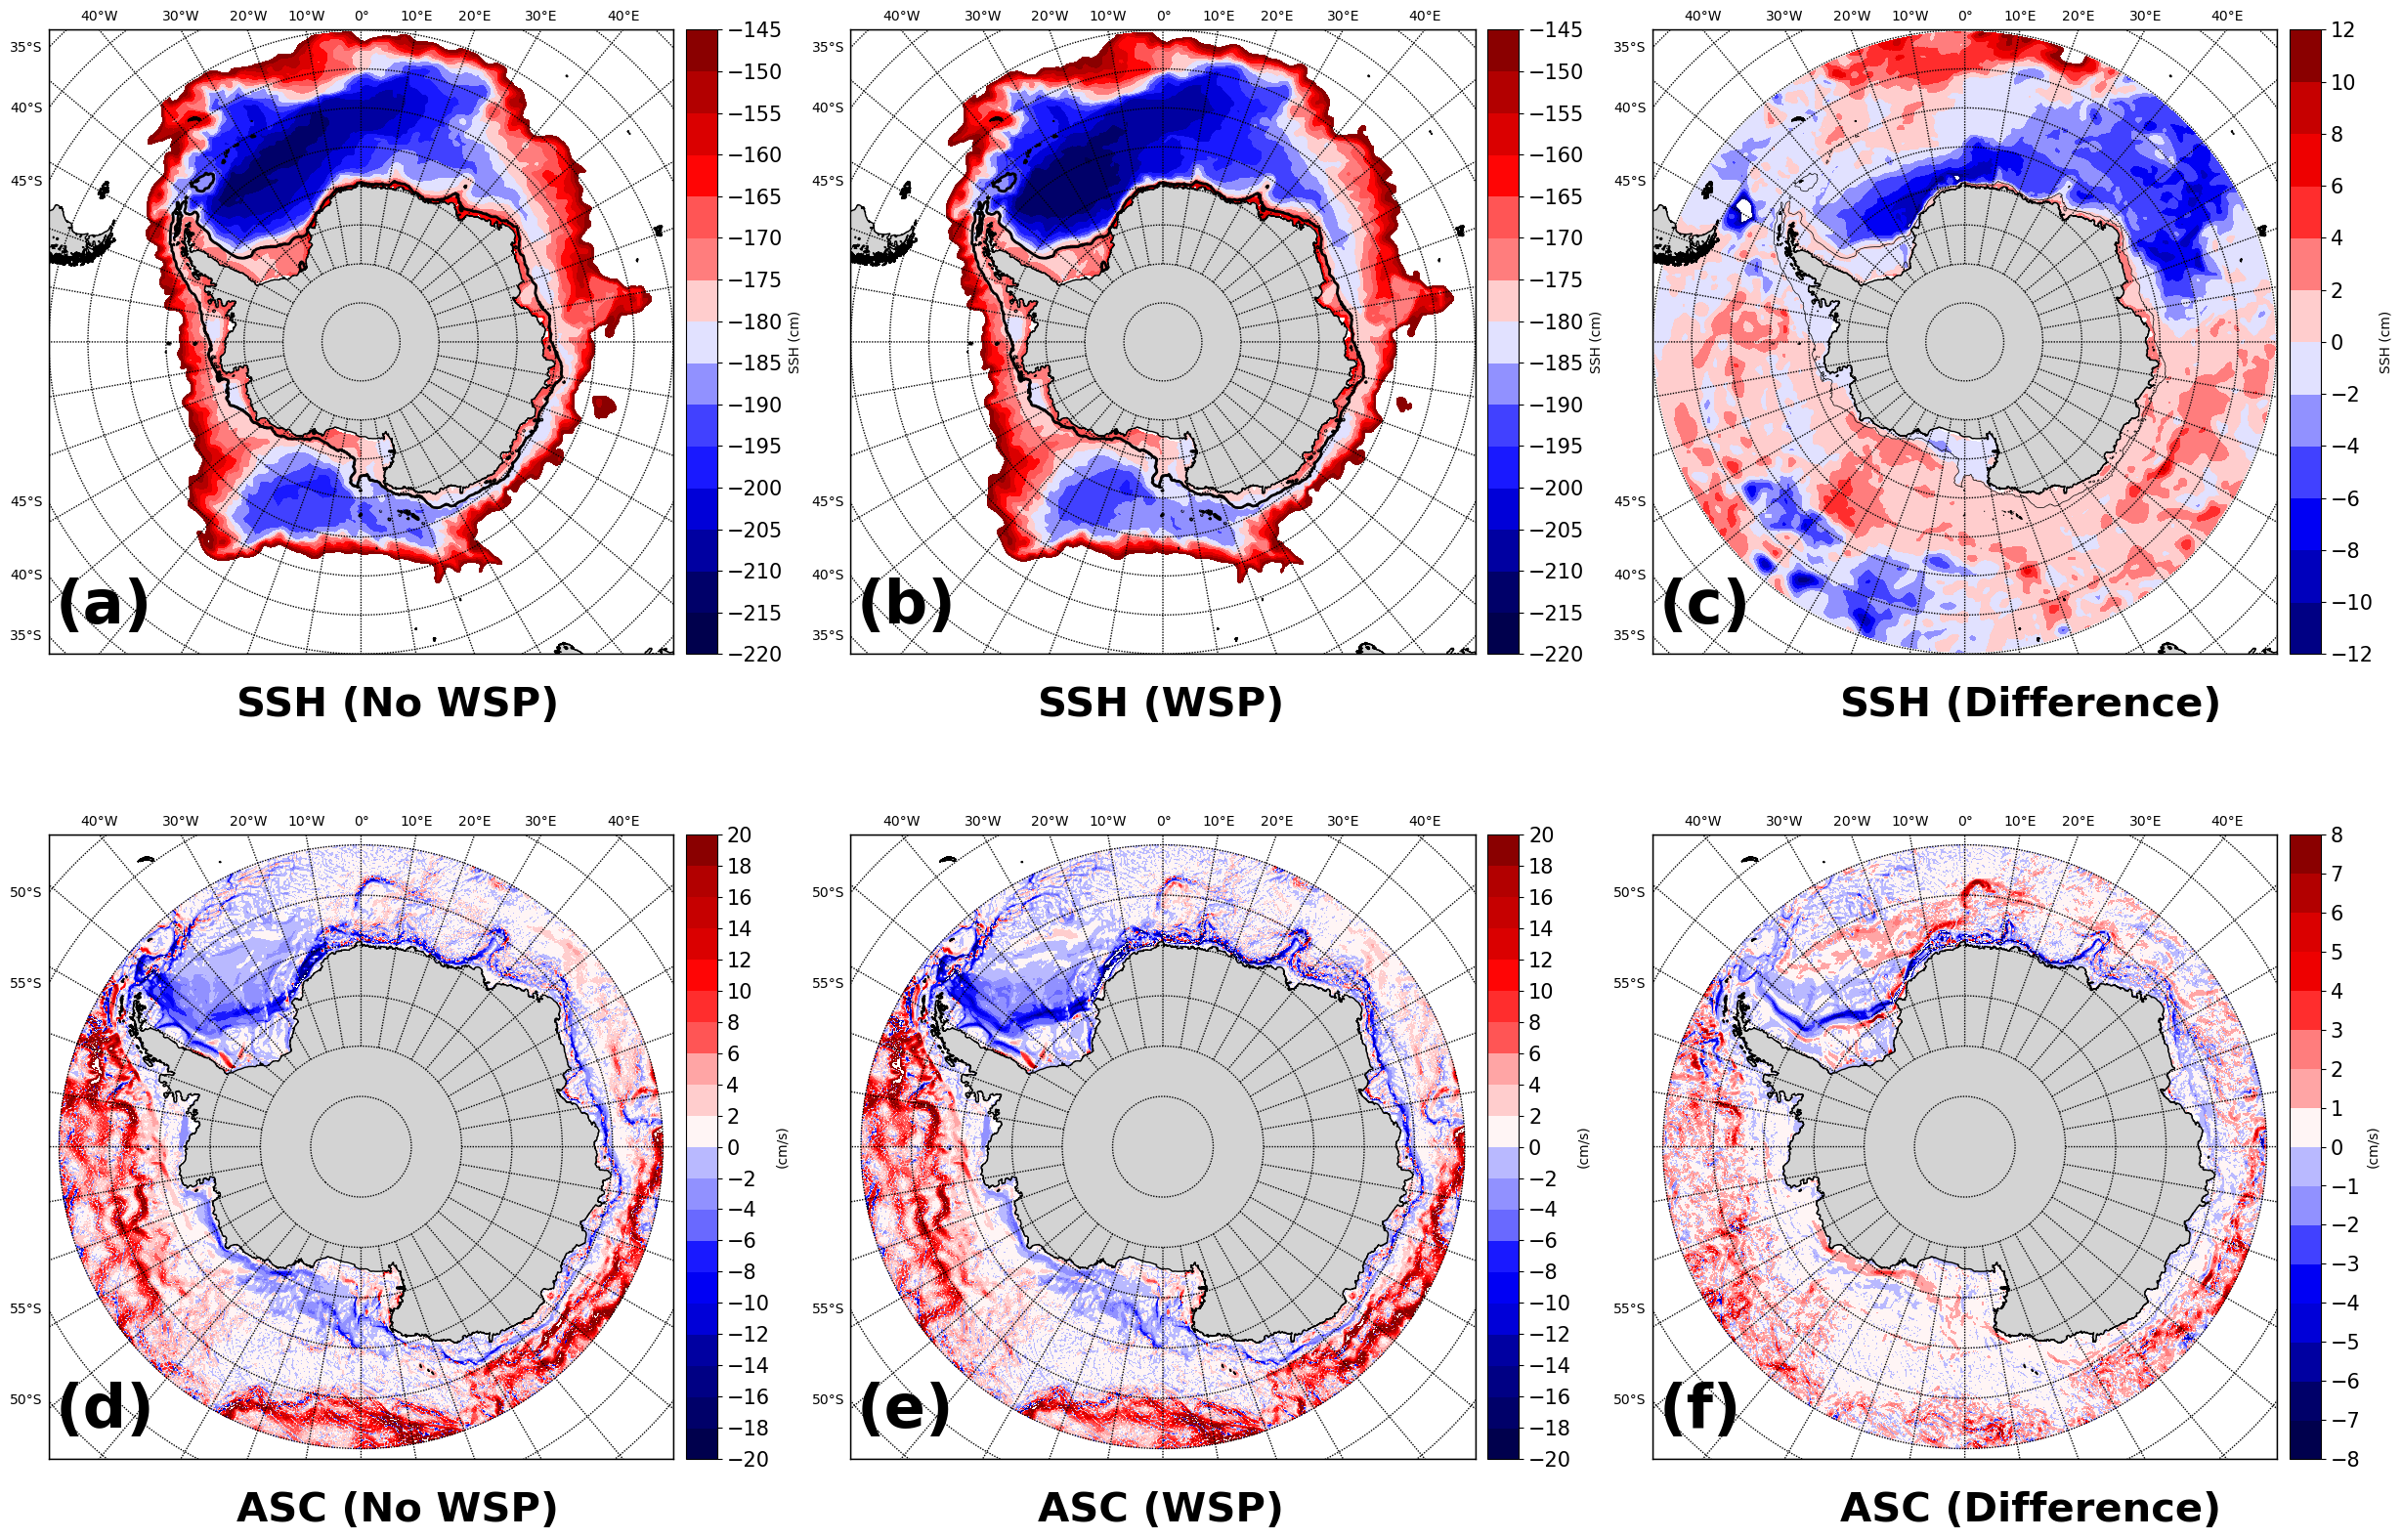

In [11]:
fig = plt.figure(figsize=(30,20), dpi=100)
#ax0 = fig.add_axes([0.1, 0.1, 0.8, 0.36],
                    #xticklabels=[])

ax1 = plt.subplot(2, 3, 5)
my_font = {'fontname':'Cambria', 'size':'10'}
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18,20]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

my_font = {'fontname':'Cambria', 'size':'10'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 6900000,height = 6900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont,latt)
CP = map.contourf(x,y,ASCyesm[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('(cm/s)', **my_font)

#ax1.text(0.05, 0.05, '(e) ASC (WSP)', transform=ax1.transAxes,size=30, weight='bold',color='purple')
ax1.text(0.01, 0.05, '(e)', transform=ax1.transAxes,size=45, weight='bold',color='black')
ax1.text(0.3, -0.1, 'ASC (WSP)', transform=ax1.transAxes,size=30, weight='bold',color='black')

ax2 = plt.subplot(2, 3, 4)
my_font = {'fontname':'Cambria', 'size':'10'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18,20]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

my_font = {'fontname':'Cambria', 'size':'10'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 6900000,height = 6900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont,latt)
CP = map.contourf(x,y,ASCnom[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('(cm/s)', **my_font)

#ax2.text(0.05, 0.05, '(d) ASC (No)', transform=ax2.transAxes,size=30, weight='bold',color='purple')
ax2.text(0.01, 0.05, '(d)', transform=ax2.transAxes,size=45, weight='bold',color='black')
ax2.text(0.3, -0.1, 'ASC (No WSP)', transform=ax2.transAxes,size=30, weight='bold',color='black')
    
ax3 = plt.subplot(2, 3, 6)
my_font = {'fontname':'Cambria', 'size':'10'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
my_font = {'fontname':'Cambria', 'size':'10'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 6900000,height = 6900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)


x,y=map(lont[:1000,:],latt[:1000,])
CP = map.contourf(x[:,:],y[:,:],ppp[:1000,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('(cm/s)', **my_font)

#ax3.text(0.05, 0.05, '(f) ASC (WSP-No)', transform=ax3.transAxes,size=30, weight='bold',color='purple')

ax3.text(0.01, 0.05, '(f)', transform=ax3.transAxes,size=45, weight='bold',color='black')
ax3.text(0.3, -0.1, 'ASC (Difference)', transform=ax3.transAxes,size=30, weight='bold',color='black')
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-220,-215,-210,-205,-200,-195,-190,-185,-180,-175,-170,-165,-160,-155,-150,-145]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

ax0 = plt.subplot(2, 3, 1)
my_font = {'fontname':'Cambria', 'size':'10'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8900000,height = 8900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x,y,iceno[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('SSH (cm)', **my_font)
xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarKMT[:428,:],[40],colors= 'black',linestyles = 'solid',linewidths=2)
#ax0.text(0.05, 0.05, '(a) SSH (No)', transform=ax0.transAxes,size=30, weight='bold',color='purple')

ax0.text(0.01, 0.05, '(a)', transform=ax0.transAxes,size=45, weight='bold',color='black')
ax0.text(0.3, -0.1, 'SSH (No WSP)', transform=ax0.transAxes,size=30, weight='bold',color='black')

#ax0.text(0.42, 0.48, 'TAUX', transform=ax0.transAxes,size=20, weight='bold')
##############################################################################
#ee = map.contour(x,y,meaddd,[32.65], colors='darkgreen')
ax0 = plt.subplot(2, 3, 2)
my_font = {'fontname':'Cambria', 'size':'10'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8900000,height = 8900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x,y,ice[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('SSH (cm)', **my_font)
xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarKMT[:428,:],[40],colors= 'black',linestyles = 'solid',linewidths=2)
#ax0.text(0.05, 0.05, '(b) SSH (WSP)', transform=ax0.transAxes,size=30, weight='bold',color='purple')

ax0.text(0.01, 0.05, '(b)', transform=ax0.transAxes,size=45, weight='bold',color='black')
ax0.text(0.3, -0.1, 'SSH (WSP)', transform=ax0.transAxes,size=30, weight='bold',color='black')
#plt.savefig("ice222.png",bbox_inches='tight')

#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################


ax0 = plt.subplot(2, 3, 3)
my_font = {'fontname':'Cambria', 'size':'10'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 8900000,height = 8900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x,y,icediff[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('SSH (cm)', **my_font)
xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarKMT[:428,:],[40],colors= 'black',linestyles = 'solid',linewidths=0.5)
ax0.text(0.01, 0.05, '(c)', transform=ax0.transAxes,size=45, weight='bold',color='black')
ax0.text(0.3, -0.1, 'SSH (Difference)', transform=ax0.transAxes,size=30, weight='bold',color='black')

plt.savefig("FigSSS2.png",bbox_inches='tight')

In [12]:
pwd

'/home/dell/iHESPplot/Paper3'